In [16]:
from pinnsform.util import *
from pinnsform.model import PINNsformer, PINNsformerNoAttention
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
%matplotlib inline

def load_csv_to_numpy(file_path):
    df = pd.read_csv(file_path, header=None, index_col=None, sep=",")
    return np.array(df.values)

In [17]:
base_dir_pre = os.getcwd()
base_dir = os.path.join(base_dir_pre, '..')

script_labels = ["PINNFORMER_VAR_TS_LBFGS_200", "PINNFORMER_DeltaT_TS_LBFGS_200", "PINNFORMER_SeqK_TS_LBFGS_100"]
experiment_paths = {
    "PINNsformer" : os.path.join(base_dir, "results", "PINNFORMER_VAR_TS_LBFGS_200", "run", "PINNsformer"),
    "PINNsformerNoAttention" : os.path.join(base_dir, "results", "PINNFORMER_VAR_TS_LBFGS_200", "run", "PINNsformerNoAttention"),
    "NoSequence_PINNsformer" : os.path.join(base_dir, "results", "PINNFORMER_VAR_TS_LBFGS_200", "run", "NoSequence_PINNsformer"),
    "PINNsformerOnlyEncoder" :  os.path.join(base_dir, "results", "PINNFORMER_VAR_TS_LBFGS_200", "OnlyEncoder", "PINNsformerOnlyEncoder"),
    "PINNsformerSmall1Head" : os.path.join(base_dir, "results", "PINNFORMER_VAR_TS_LBFGS_200", "small1head", "smallPINNsformer1head")
}

In [18]:
device = 'cpu'

pinnsformers = PINNsformer(d_out=1, d_hidden=512, d_model=32, N=1, heads=2).to(device)

NUM_SEEDS = 100
INIT_SEEDS = np.array(range(NUM_SEEDS))

In [19]:
'''def visualize_mesh(mesh, mesh_shape, domain, file_name = 'analytic'):
    reshaped_mesh = np.reshape(mesh, mesh_shape)
    #[0,np.pi*2,1,0]
    plt.figure(figsize=(4,3))
    domain_extend = [domain[1][0], domain[1][1], domain[0][0], domain[0][1]]
    plt.imshow(reshaped_mesh, extent=domain_extend, aspect='auto')
    plt.xlabel('t')
    plt.ylabel('x')
    #plt.title('u(x,t)')
    plt.colorbar()
    plt.tight_layout()
    plt.savefig('./plots/'+file_name+'.png', dpi=400)
    plt.show()
'''
def visualize_mesh(mesh, mesh_shape, domain, norm = None, cmap = "viridis", scaling = (0.0, 1.0), file_name = 'analytic'):
    reshaped_mesh = np.reshape(mesh, mesh_shape)
    #[0,np.pi*2,1,0]
    plt.figure(figsize=(4,3))
    domain_extend = [domain[1][0], domain[1][1], domain[0][0], domain[0][1]]
    if scaling:
        plt.imshow(reshaped_mesh, norm = norm, cmap=cmap, extent=domain_extend, vmin=scaling[0], vmax=scaling[1], aspect='auto')
    else:
        plt.imshow(reshaped_mesh, norm = norm, cmap=cmap, extent=domain_extend, aspect='auto')
    plt.xlabel('t')
    plt.ylabel('x')
    #plt.title('u(x,t)')
    cb = plt.colorbar()
    cb.ax.set_yscale('linear')
    plt.tight_layout()
    plt.savefig('./plots/'+file_name+'.png', dpi=400)
    plt.show()

def get_solution_of_seed(model, path, seed, mesh):
    model.load_state_dict(torch.load(os.path.join(path, f"seed_{seed}", "model_at_200.pth")))
    sequence_prediction = f(model, mesh).detach().numpy()
    return sequence_prediction[:,0]


In [20]:
RHO = 5.0

def h(x):
    return np.exp( - (x-np.pi)**2 / (2 * (np.pi/4)**2))

def u_ana(x,t):
    return h(x) * np.exp(RHO*t) / ( h(x) * np.exp(RHO*t) + 1 - h(x))

problem_domain = ([0, 2*np.pi], [0, 1])

problem_name = "1Dreaction"


test_shape = (201, 201)
test_mesh, _ = generate_mesh_object(test_shape, domain=problem_domain, device=device, full_requires_grad=False, border_requires_grad=False, num_seq_steps=5, seq_step_size=1e-3)
analytic_solution = u_ana(test_mesh.part[0][:,0].cpu().numpy(), test_mesh.part[1][:,0].cpu().numpy())

#visualize_mesh(analytic_solution, test_shape, problem_domain, file_name='analytic')

#visualize_solution_of_seed(pinn, pinn_path, 0, )

In [21]:
def model_solution_diff_visualization(model, model_name, model_path, good_bad_indices):
    good_prediction = get_solution_of_seed(model, model_path, good_bad_indices[0], test_mesh)
    bad_prediction = get_solution_of_seed(model, model_path, good_bad_indices[1], test_mesh)
    good_diff = analytic_solution - good_prediction
    bad_diff = analytic_solution - bad_prediction
    
    visualize_mesh(good_diff, test_shape, problem_domain, norm = TwoSlopeNorm(0, -1, 1), cmap='twilight_shifted_r', scaling=None, file_name=f'{problem_name}_{model_name}_good({good_bad_indices[0]})_diff')
    visualize_mesh(bad_diff, test_shape, problem_domain, norm = TwoSlopeNorm(0, -1, 1), cmap='twilight_shifted_r', scaling=None, file_name=f'{problem_name}_{model_name}_bad({good_bad_indices[1]})_diff')
    visualize_mesh(good_prediction, test_shape, problem_domain, file_name=f'{problem_name}_{model_name}_good({good_bad_indices[0]})')
    visualize_mesh(bad_prediction, test_shape, problem_domain, file_name=f'{problem_name}_{model_name}_bad({good_bad_indices[1]})')

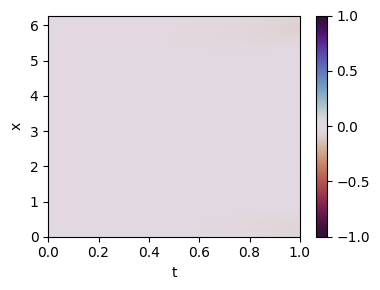

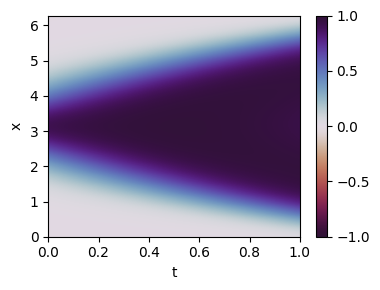

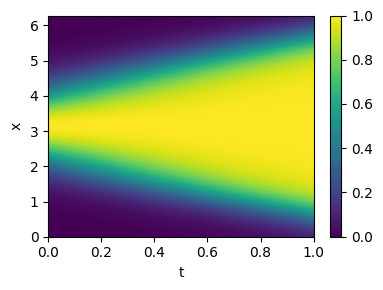

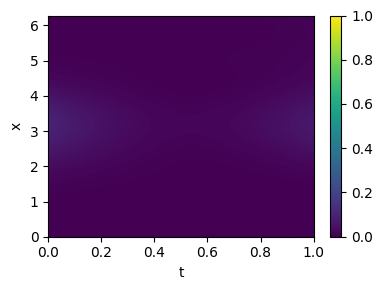

In [22]:
model_solution_diff_visualization(pinnsformers, "PINNsformer", experiment_paths["PINNsformer"], (61,99))

In [6]:
rmae_list = []
for i in INIT_SEEDS:
    rmae_path = os.path.join(experiment_paths["PINNsformer"], f"seed_{i}", "error.csv")
    data = load_csv_to_numpy(rmae_path)
    rmae_list.append(float(data[1,0]))

print(np.argmin(rmae_list))

61


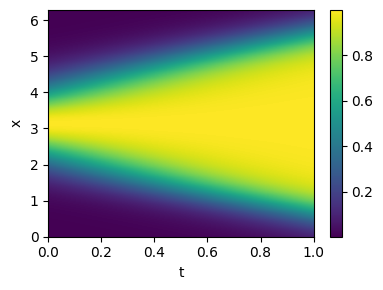

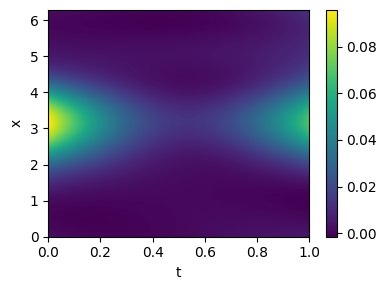

In [11]:
goodseed = 61
badseed = 99
good_prediction = get_solution_of_seed(pinnsformers, experiment_paths["PINNsformer"], goodseed, test_mesh)
bad_prediction = get_solution_of_seed(pinnsformers, experiment_paths["PINNsformer"], badseed, test_mesh)

visualize_mesh(good_prediction, test_shape, problem_domain, file_name=f'PINNsformer_good({goodseed})')
visualize_mesh(bad_prediction, test_shape, problem_domain, file_name=f'PINNsformer_bad({badseed})')